# Algoritmos de Optimización - Seminario

**Nombre y Apellidos** *(trabajo en grupo de 2)*:

- Diego Abel Cañete Vera
- Jaime Eduardo Cardona Buenaventura

**Url:** https://github.com/diegoaz33/03MIAR-Algoritmos-Optimizacion/tree/main/SEMINARIO

**Problema elegido:**
> 1. **Sesiones de doblaje**  — PROBLEMA ELEGIDO
> 2. Organizar los horarios de partidos de La Liga
> 3. Combinar cifras y operaciones

## Descripción del problema *(enunciado)*

Se precisa coordinar el doblaje de una película. Los actores de doblaje deben coincidir en las tomas en las que sus personajes aparecen juntos. Cada actor cobra una cantidad fija por **cada día** que debe desplazarse hasta el estudio de grabación, **independientemente del número de tomas** que se graben ese día. No es posible grabar **más de 6 tomas por día**. El objetivo es **planificar las sesiones por día de manera que el gasto por los servicios de los actores sea el menor posible**.

Datos:

- **Número de actores:** 10
- **Número de tomas:** 30
- **Matriz de participación *Actores/Tomas*** (`1` = el actor participa en la toma; `0` = no participa). Fuente: https://bit.ly/36D8IuK

**Observación clave para el modelado del coste.** Como cada actor paga por *día asistido*, el gasto total (medido en **actor-días**) es:

$$\text{coste} = \sum_{\text{día } d}\big(\text{nº de actores distintos que participan en alguna toma del día } d\big)$$

Por tanto, minimizar el gasto equivale a **agrupar en el mismo día las tomas que comparten más actores** (así esos actores hacen un único desplazamiento).

*(\*) La respuesta es obligatoria.*


## 1. Análisis del espacio de soluciones

### (\*) ¿Cuántas posibilidades hay sin tener en cuenta las restricciones?

Una "posibilidad" es una forma de **agrupar** las 30 tomas en días. Los días **no están etiquetados**: sólo importa *qué tomas se graban juntas* (grabar `{toma1, toma2}` el lunes o el martes cuesta lo mismo). Cada solución candidata es, pues, una **partición del conjunto** de las 30 tomas.

El número de particiones de un conjunto de $n$ elementos es el **número de Bell** $B(n)$. Sin ninguna restricción:

$$\text{posibilidades} = B(30) \approx 8.47 \times 10^{23}$$

*(Más de 800 mil trillones. Nota: si los días fueran distinguibles y su número fijo, el conteo sería otro —números de Stirling—, pero el modelo natural del problema, con días intercambiables, corresponde al número de Bell.)*

### ¿Cuántas posibilidades hay teniendo en cuenta todas las restricciones?

La restricción estructural sobre la partición es **"máximo 6 tomas por día"**. Hay que contar sólo las particiones cuyos bloques tienen tamaño $\le 6$. Ese número se obtiene con la recurrencia (el bloque que contiene al último elemento tiene tamaño $j$: se eligen sus $j-1$ compañeros y se particiona el resto):

$$a(n)=\sum_{j=1}^{\min(n,6)}\binom{n-1}{j-1}\,a(n-j),\qquad a(0)=1$$

El valor exacto para $n=30,\ k=6$ se calcula abajo (sigue siendo astronómico, del orden de $10^{23}$). El **nº mínimo de días** es $\lceil 30/6\rceil = 5$.


In [1]:
# =====================================================================
#  Conteo del espacio de soluciones (combinatoria)
# =====================================================================
from math import comb
from functools import lru_cache

def numero_de_bell(n):
    """Número de Bell B(n): nº de particiones de un conjunto de n elementos.
    Se calcula con el triángulo de Bell."""
    fila = [1]
    for _ in range(n):
        nueva = [fila[-1]]
        for x in fila:
            nueva.append(nueva[-1] + x)
        fila = nueva
    return fila[0]

def particiones_con_bloques_acotados(n, k):
    """Nº de particiones de un conjunto de n elementos en las que NINGÚN
    bloque supera el tamaño k (recurrencia por el bloque del último elemento)."""
    @lru_cache(maxsize=None)
    def a(m):
        if m == 0:
            return 1
        return sum(comb(m - 1, j - 1) * a(m - j) for j in range(1, min(m, k) + 1))
    return a(n)

N, K = 30, 6
sin_restr = numero_de_bell(N)
con_restr = particiones_con_bloques_acotados(N, K)

print(f"Posibilidades SIN restricciones  (B(30))            = {sin_restr:,}")
print(f"   aprox. {sin_restr:.3e}")
print()
print(f"Posibilidades CON restriccion (bloques <= 6 tomas)  = {con_restr:,}")
print(f"   aprox. {con_restr:.3e}")
print()
print(f"Nº minimo de dias necesarios = techo(30/6) = {-(-N // K)}")


Posibilidades SIN restricciones  (B(30))            = 846,749,014,511,809,332,450,147
   aprox. 8.467e+23

Posibilidades CON restriccion (bloques <= 6 tomas)  = 726,391,948,970,868,949,621,309
   aprox. 7.264e+23

Nº minimo de dias necesarios = techo(30/6) = 5


## 2. Modelo del espacio de soluciones y estructura de datos

### (\*) ¿Cuál es la estructura de datos que mejor se adapta al problema?

**Representación de los datos de entrada.** Cada toma queda definida por el *conjunto* de actores que participan en ella. La operación central del problema es: dado un conjunto de tomas asignadas a un día, calcular cuántos actores **distintos** intervienen (la **unión** de sus conjuntos de actores). Esto sugiere de forma natural representar cada toma como un **conjunto** (`set`) de actores.

**Optimización elegida — máscaras de bits (`bitmask`).** Como sólo hay 10 actores, cada toma se codifica como un **entero de 10 bits**, donde el bit $j$ vale 1 si el actor $j$ participa. Con esta representación las tres operaciones que dominan el cálculo son inmediatas:

| Operación | Con `set` | Con `bitmask` |
|---|---|---|
| Unión de actores de un día | `a | b` | `a | b` (OR de enteros) |
| Nº de actores distintos | `len(union)` | `popcount(union)` |
| Actores compartidos (intersección) | `a & b` | `a & b` |

El `bitmask` es **más rápido y compacto**: la unión es un simple `OR` y el recuento de actores un `popcount` (prácticamente O(1) para 10 bits), frente al coste de gestionar tablas hash de los `set`. Empecé razonando con conjuntos por su claridad conceptual y **cambié a máscaras de bits** al ver que unión/intersección/recuento se ejecutan millones de veces dentro de los algoritmos de búsqueda.

**Representación de una solución.** Una planificación es una **lista de días**, y cada día una **lista de índices de tomas**: `[[0,5,6],[1,2], ...]`. Es la estructura natural de una partición: permite recorrer días, medir su tamaño ($\le 6$) y calcular su coste directamente.


In [2]:
# =====================================================================
#  Datos de entrada y utilidades base (representación con bitmask)
# =====================================================================

# Matriz de participacion Actores/Tomas  (fuente: https://bit.ly/36D8IuK)
# Filas = tomas (1..30). Columnas = actores (1..10). 1 = participa, 0 = no.
M = [
    [1,1,1,1,1,0,0,0,0,0],  #  Toma 1
    [0,0,1,1,1,0,0,0,0,0],  #  Toma 2
    [0,1,0,0,1,0,1,0,0,0],  #  Toma 3
    [1,1,0,0,0,0,1,1,0,0],  #  Toma 4
    [0,1,0,1,0,0,0,1,0,0],  #  Toma 5
    [1,1,0,1,1,0,0,0,0,0],  #  Toma 6
    [1,1,0,1,1,0,0,0,0,0],  #  Toma 7
    [1,1,0,0,0,1,0,0,0,0],  #  Toma 8
    [1,1,0,1,0,0,0,0,0,0],  #  Toma 9
    [1,1,0,0,0,1,0,0,1,0],  #  Toma 10
    [1,1,1,0,1,0,0,1,0,0],  #  Toma 11
    [1,1,1,1,0,1,0,0,0,0],  #  Toma 12
    [1,0,0,1,1,0,0,0,0,0],  #  Toma 13
    [1,0,1,0,0,1,0,0,0,0],  #  Toma 14
    [1,1,0,0,0,0,1,0,0,0],  #  Toma 15
    [0,0,0,1,0,0,0,0,0,1],  #  Toma 16
    [1,0,1,0,0,0,0,0,0,0],  #  Toma 17
    [0,0,1,0,0,1,0,0,0,0],  #  Toma 18
    [1,0,1,0,0,0,0,0,0,0],  #  Toma 19
    [1,0,1,1,1,0,0,0,0,0],  #  Toma 20
    [0,0,0,0,0,1,0,1,0,0],  #  Toma 21
    [1,1,1,1,0,0,0,0,0,0],  #  Toma 22
    [1,0,1,0,0,0,0,0,0,0],  #  Toma 23
    [0,0,1,0,0,1,0,0,0,0],  #  Toma 24
    [1,1,0,1,0,0,0,0,0,1],  #  Toma 25
    [1,0,1,0,1,0,0,0,1,0],  #  Toma 26
    [0,0,0,1,1,0,0,0,0,0],  #  Toma 27
    [1,0,0,1,0,0,0,0,0,0],  #  Toma 28
    [1,0,0,0,1,1,0,0,0,0],  #  Toma 29
    [1,0,0,1,0,0,0,0,0,0],  #  Toma 30
]

N_TOMAS   = len(M)        # 30 tomas
N_ACTORES = len(M[0])     # 10 actores
MAX_POR_DIA = 6           # restriccion: <= 6 tomas por dia

def fila_a_bitmask(fila):
    """Convierte una fila 0/1 en un entero (bit j <-> actor j)."""
    mascara = 0
    for j, participa in enumerate(fila):
        if participa:
            mascara |= (1 << j)
    return mascara

def popcount(x):
    """Numero de bits a 1 = numero de actores presentes en la mascara."""
    return bin(x).count("1")

# Precalculamos la mascara de cada toma UNA sola vez
TOMAS = [fila_a_bitmask(fila) for fila in M]

def actores_de_dia(dia, tomas):
    """Mascara con la UNION de actores de todas las tomas de un dia."""
    union = 0
    for t in dia:
        union |= tomas[t]
    return union

def coste_dia(dia, tomas):
    """Coste de un dia = nº de actores distintos que se desplazan ese dia."""
    return popcount(actores_de_dia(dia, tomas))

def coste(planificacion, tomas):
    """FUNCION OBJETIVO: coste total (actor-dias) de una planificacion."""
    return sum(coste_dia(dia, tomas) for dia in planificacion)

def es_valida(planificacion, n_tomas, max_por_dia=MAX_POR_DIA):
    """Cada dia tiene <=6 tomas y cada toma aparece exactamente una vez."""
    todas = []
    for dia in planificacion:
        if len(dia) > max_por_dia:
            return False
        todas.extend(dia)
    return sorted(todas) == list(range(n_tomas))

# --- Comprobacion rapida de la carga de datos ---
print(f"Tomas: {N_TOMAS} | Actores: {N_ACTORES} | Max tomas/dia: {MAX_POR_DIA}")
print("Actores por toma:", [popcount(t) for t in TOMAS])
print("Veces que trabaja cada actor:",
      [sum(fila[j] for fila in M) for j in range(N_ACTORES)])


Tomas: 30 | Actores: 10 | Max tomas/dia: 6
Actores por toma: [5, 3, 3, 4, 3, 4, 4, 3, 3, 4, 5, 5, 3, 3, 3, 2, 2, 2, 2, 4, 2, 4, 2, 2, 4, 4, 2, 2, 3, 2]
Veces que trabaja cada actor: [22, 14, 13, 15, 11, 8, 3, 4, 2, 2]


## 3. Función objetivo. ¿Maximización o minimización?

### (\*) ¿Cuál es la función objetivo?

$$f(\text{planificación})=\sum_{d\,\in\,\text{días}}\Big|\;\bigcup_{t\in d}\text{Actores}(t)\;\Big|$$

Es decir, la suma —sobre todos los días— del número de actores distintos que acuden cada día (el total de **actor-días** facturados). En el código es la función `coste()`.

### (\*) ¿Es un problema de maximización o minimización?

Es un problema de **MINIMIZACIÓN**: buscamos que el gasto por los desplazamientos de los actores sea el **menor** posible, sujeto a la restricción de $\le 6$ tomas por día.


In [3]:
# Ejemplo A: una toma por dia (30 dias) -> el peor caso / cota superior trivial
plan_trivial = [[t] for t in range(N_TOMAS)]
print("Plan trivial (30 dias, 1 toma/dia):")
print("  valida?", es_valida(plan_trivial, N_TOMAS),
      "| coste =", coste(plan_trivial, TOMAS), "actor-dias")

# Ejemplo B: agrupar las tomas de 6 en 6 en el orden dado (5 dias)
plan_secuencial = [list(range(i, min(i + 6, N_TOMAS))) for i in range(0, N_TOMAS, 6)]
print("\nPlan secuencial (tomas 1-6, 7-12, ...):")
print("  dias =", plan_secuencial)
print("  valida?", es_valida(plan_secuencial, N_TOMAS),
      "| coste =", coste(plan_secuencial, TOMAS), "actor-dias")


Plan trivial (30 dias, 1 toma/dia):
  valida? True | coste = 94 actor-dias

Plan secuencial (tomas 1-6, 7-12, ...):
  dias = [[0, 1, 2, 3, 4, 5], [6, 7, 8, 9, 10, 11], [12, 13, 14, 15, 16, 17], [18, 19, 20, 21, 22, 23], [24, 25, 26, 27, 28, 29]]
  valida? True | coste = 38 actor-dias


## 4. Algoritmo por fuerza bruta

### Diseño

La fuerza bruta **enumera todas las particiones válidas** (todos los repartos de las tomas en días con $\le 6$ tomas/día), evalúa la función objetivo en cada una y se queda con la de **menor coste**. Garantiza el óptimo global porque examina el espacio completo.

Generamos las particiones de forma **recursiva**: se procesa toma a toma y, para cada partición del resto, la nueva toma se coloca **(a)** en un día nuevo, o **(b)** en uno de los días ya existentes que aún tenga hueco ($< 6$ tomas). Esta construcción canónica genera cada partición **exactamente una vez**.


In [4]:
# =====================================================================
#  Algoritmo por FUERZA BRUTA  (optimo, pero solo viable para n pequeño)
# =====================================================================

def generar_particiones(elementos, max_por_dia=MAX_POR_DIA):
    """Genera TODAS las particiones de 'elementos' con bloques de tamaño
    <= max_por_dia. Construccion canonica (elemento a elemento) => sin duplicados."""
    if not elementos:
        yield []
        return
    primero, resto = elementos[0], elementos[1:]
    for sub in generar_particiones(resto, max_por_dia):
        # (a) 'primero' abre un dia nuevo
        yield [[primero]] + sub
        # (b) 'primero' se une a un dia existente que tenga hueco
        for i in range(len(sub)):
            if len(sub[i]) < max_por_dia:
                yield sub[:i] + [[primero] + sub[i]] + sub[i+1:]

def fuerza_bruta(indices, tomas, max_por_dia=MAX_POR_DIA):
    """Devuelve (mejor_planificacion, mejor_coste) explorando TODO el espacio."""
    mejor_plan, mejor_coste = None, float("inf")
    for plan in generar_particiones(list(indices), max_por_dia):
        c = coste(plan, tomas)
        if c < mejor_coste:
            mejor_coste, mejor_plan = c, plan
    return mejor_plan, mejor_coste

# La fuerza bruta es INVIABLE para 30 tomas (B(30) ~ 10^23).
# La demostramos sobre un subconjunto pequeño: las primeras 8 tomas.
import time

sub = list(range(8))
t0 = time.perf_counter()
plan_opt, coste_opt = fuerza_bruta(sub, TOMAS)
t1 = time.perf_counter()
n_part = sum(1 for _ in generar_particiones(sub))

print(f"Subproblema con {len(sub)} tomas:")
print(f"  Particiones exploradas = {n_part:,}")
print(f"  Planificacion optima   = {plan_opt}")
print(f"  Coste optimo           = {coste_opt} actor-dias")
print(f"  Tiempo                 = {t1 - t0:.4f} s")


Subproblema con 8 tomas:
  Particiones exploradas = 4,131
  Planificacion optima   = [[2, 3, 4, 5, 6], [0, 1, 7]]
  Coste optimo           = 12 actor-dias
  Tiempo                 = 0.0117 s


### (\*) Complejidad del algoritmo por fuerza bruta

El número de particiones a explorar es (sin la cota de tamaño) el número de Bell $B(n)$, que crece de forma **super-exponencial**. Evaluar el coste de cada partición cuesta $O(n)$ (recorrer las tomas y hacer OR de máscaras). Por tanto:

$$T_{\text{fuerza bruta}}(n)=\Theta\big(B(n)\cdot n\big)$$

Como referencia, aunque $B(n) < n!$, sigue siendo peor que exponencial:

| $n$ | $B(n)$ |
|---|---|
| 8 | 4 140 |
| 15 | $\sim 1.4\times10^{6}$ |
| 30 | $\sim 8.5\times10^{23}$ |

Para $n=30$, aunque evaluásemos **mil millones de particiones por segundo**, tardaríamos del orden de **millones de años**. La fuerza bruta es, pues, **intratable** para el tamaño real y sólo sirve como referencia de optimalidad en instancias pequeñas.


## 5. Algoritmo mejorado

### (\*) Diseño: voraz aglomerativo por "ahorro" + búsqueda local

**Idea clave (por qué mejora).** Juntar dos días $A$ y $B$ en uno solo cuesta $|A\cup B|$ actores, frente a $|A|+|B|$ si van separados. Por **inclusión-exclusión**, el **ahorro** de fusionarlos es exactamente:

$$|A|+|B|-|A\cup B| \;=\; |A\cap B|\qquad(\text{= actores que comparten})$$

Es decir: **fusionar dos días ahorra tantos desplazamientos como actores tengan en común**. De ahí nace la heurística:

- **Fase 1 — Voraz aglomerativo.** Empezamos con una toma por día. Repetidamente fusionamos el par de días con **mayor número de actores compartidos** (máximo ahorro), siempre que el día resultante no supere las 6 tomas. Paramos cuando ninguna fusión factible aporta ahorro.
- **Fase 2 — Búsqueda local (refinamiento).** Partiendo de la solución voraz exploramos dos tipos de movimiento: **(i) reubicar** una toma en otro día con hueco (*relocate*) y **(ii) intercambiar** dos tomas entre días distintos (*swap*). Aplicamos el mejor movimiento que reduzca el coste y repetimos hasta un **óptimo local**. El *swap* es imprescindible aquí: cuando el voraz llena todos los días a 6 tomas, ningún *relocate* es aplicable (no quedan huecos) y sólo los intercambios permiten seguir mejorando.

**Por qué mejora a la fuerza bruta.** En lugar de enumerar las $\sim 10^{23}$ particiones, tomamos **decisiones locales guiadas por el ahorro**. Esto reduce el tiempo de *super-exponencial* a **polinómico**, obteniendo soluciones de alta calidad (más abajo se valida que igualan o casi igualan al óptimo en instancias pequeñas) a cambio de renunciar a la garantía de optimalidad global.

**Cota inferior (para valorar la calidad).** El actor $a$ aparece en $k_a$ tomas; como cada día admite $\le 6$ tomas, sus tomas ocupan al menos $\lceil k_a/6\rceil$ días. Luego:

$$\text{coste óptimo}\;\ge\;\sum_{a}\Big\lceil \tfrac{k_a}{6}\Big\rceil$$


In [5]:
# =====================================================================
#  Algoritmo MEJORADO - Fase 1: voraz aglomerativo por ahorro
# =====================================================================

def voraz(tomas, max_por_dia=MAX_POR_DIA):
    """Fusiona iterativamente los dos dias que MAS actores comparten
    (maximo ahorro), respetando el limite de 6 tomas/dia."""
    n = len(tomas)
    dias    = [[t] for t in range(n)]       # cada toma en su propio dia
    uniones = [tomas[t] for t in range(n)]  # mascara de actores de cada dia

    while True:
        mejor_ahorro, mejor_par = 0, None
        # Buscar el par de dias con mas actores compartidos y hueco suficiente
        for i in range(len(dias)):
            for j in range(i + 1, len(dias)):
                if len(dias[i]) + len(dias[j]) <= max_por_dia:
                    compartidos = popcount(uniones[i] & uniones[j])
                    if compartidos > mejor_ahorro:
                        mejor_ahorro, mejor_par = compartidos, (i, j)
        if mejor_par is None:      # no queda fusion factible con ahorro > 0
            break
        i, j = mejor_par
        dias[i]    += dias[j]       # fusionar el dia j dentro del dia i
        uniones[i] |= uniones[j]
        del dias[j]
        del uniones[j]

    return dias, coste(dias, tomas)

plan_voraz, coste_voraz = voraz(TOMAS)
print("FASE 1 - Voraz aglomerativo")
print(f"  Nº de dias = {len(plan_voraz)}")
print(f"  valida?    = {es_valida(plan_voraz, N_TOMAS)}")
print(f"  Coste      = {coste_voraz} actor-dias")


FASE 1 - Voraz aglomerativo
  Nº de dias = 5
  valida?    = True
  Coste      = 31 actor-dias


In [6]:
# =====================================================================
#  Algoritmo MEJORADO - Fase 2: busqueda local (mover tomas entre dias)
# =====================================================================

def busqueda_local(planificacion, tomas, max_por_dia=MAX_POR_DIA):
    """Mejora una planificacion con DOS tipos de movimiento:
      (i)  RELOCATE: mover una toma a otro dia con hueco.
      (ii) SWAP    : intercambiar dos tomas entre dias distintos.
    Se aplica el mejor movimiento de cada pasada mientras reduzca el coste."""
    dias = [list(d) for d in planificacion]
    mejorando = True
    while mejorando:
        mejorando = False
        base = coste(dias, tomas)
        mejor_delta, mejor_config = 0, None

        # --- Vecindad 1: RELOCATE (mover una toma a otro dia con hueco) ---
        for a in range(len(dias)):
            for pa in range(len(dias[a])):
                for b in range(len(dias)):
                    if b == a or len(dias[b]) >= max_por_dia:
                        continue
                    prueba = [list(d) for d in dias]
                    prueba[b].append(prueba[a].pop(pa))
                    prueba = [d for d in prueba if d]       # quitar dias vacios
                    delta = coste(prueba, tomas) - base
                    if delta < mejor_delta:
                        mejor_delta, mejor_config = delta, prueba

        # --- Vecindad 2: SWAP (intercambiar dos tomas entre dias distintos) ---
        for a in range(len(dias)):
            for b in range(a + 1, len(dias)):
                for pa in range(len(dias[a])):
                    for pb in range(len(dias[b])):
                        prueba = [list(d) for d in dias]
                        prueba[a][pa], prueba[b][pb] = prueba[b][pb], prueba[a][pa]
                        delta = coste(prueba, tomas) - base
                        if delta < mejor_delta:
                            mejor_delta, mejor_config = delta, prueba

        if mejor_config is not None:
            dias, mejorando = mejor_config, True
    return dias, coste(dias, tomas)

plan_final, coste_final = busqueda_local(plan_voraz, TOMAS)

# Cota inferior analitica
import math
apariciones   = [sum(fila[j] for fila in M) for j in range(N_ACTORES)]
cota_inferior = sum(math.ceil(k / MAX_POR_DIA) for k in apariciones)

print("FASE 2 - Busqueda local (refinamiento)")
print(f"  Nº de dias = {len(plan_final)}")
print(f"  valida?    = {es_valida(plan_final, N_TOMAS)}")
print(f"  Coste      = {coste_final} actor-dias")
print()
print("=== RESUMEN - instancia real (30 tomas, 10 actores) ===")
print(f"  Baseline (1 toma/dia)     : {coste(plan_trivial, TOMAS):>3} actor-dias")
print(f"  Voraz (fase 1)            : {coste_voraz:>3} actor-dias")
print(f"  Voraz + busqueda local    : {coste_final:>3} actor-dias   <-- solucion propuesta")
print(f"  Cota inferior (analitica) : {cota_inferior:>3} actor-dias")
print()
print("Planificacion final (dia -> tomas, numeradas desde 1):")
for d, dia in enumerate(sorted(plan_final, key=len, reverse=True), 1):
    tomas_humanas = sorted(t + 1 for t in dia)
    print(f"  Dia {d}: {len(dia)} tomas {tomas_humanas}  ->  {coste_dia(dia, TOMAS)} actores")


FASE 2 - Busqueda local (refinamiento)
  Nº de dias = 5
  valida?    = True
  Coste      = 30 actor-dias

=== RESUMEN - instancia real (30 tomas, 10 actores) ===
  Baseline (1 toma/dia)     :  94 actor-dias
  Voraz (fase 1)            :  31 actor-dias
  Voraz + busqueda local    :  30 actor-dias   <-- solucion propuesta
  Cota inferior (analitica) :  21 actor-dias

Planificacion final (dia -> tomas, numeradas desde 1):
  Dia 1: 6 tomas [1, 6, 7, 11, 12, 20]  ->  7 actores
  Dia 2: 6 tomas [2, 9, 16, 22, 25, 26]  ->  7 actores
  Dia 3: 6 tomas [3, 4, 5, 8, 10, 15]  ->  8 actores
  Dia 4: 6 tomas [14, 17, 18, 19, 23, 24]  ->  3 actores
  Dia 5: 6 tomas [13, 21, 27, 28, 29, 30]  ->  5 actores


### (\*) Complejidad del algoritmo mejorado

**Fase 1 (voraz aglomerativo).** Cada fusión reduce en 1 el número de días, luego hay a lo sumo $n-1$ fusiones. En cada una se examinan todos los pares de días, $O(g^2)$ con $g\le n$, y evaluar los actores compartidos de un par es $O(1)$ con máscaras de bits (10 bits). Por tanto:

$$T_{\text{voraz}}(n)=O\big(n\cdot n^2\big)=O(n^3)$$

**Fase 2 (búsqueda local).** Cada pasada explora $O(n^2)$ movimientos *relocate* (toma $\times$ día) y $O(n^2)$ movimientos *swap* (pares de tomas en días distintos); cada evaluación recalcula el coste en $O(n)$, luego $O(n^3)$ por pasada. El número de pasadas está acotado (cada una reduce estrictamente un coste entero y acotado), así que también es **polinómica**.

En conjunto el algoritmo es **polinómico, $O(n^3)$**, frente al $\Theta(B(n)\cdot n)$ super-exponencial de la fuerza bruta. Esa es la mejora esencial: pasar de *intratable* a *resoluble en milisegundos*, incluso para cientos de tomas (se comprueba en la sección de escalabilidad).


## 6. Juego de datos de entrada aleatorios

### Diseño

Generamos matrices de participación *Actores/Tomas* aleatorias, parametrizadas por:

- `n_tomas`, `n_actores`: dimensiones del problema,
- `densidad`: probabilidad de que un actor participe en una toma,
- `semilla`: para reproducibilidad.

Se garantiza que **ninguna toma quede vacía** (cada toma tiene al menos un actor), pues una toma sin actores no tendría sentido. Esto permite estudiar el comportamiento del algoritmo al variar tamaño y densidad.


In [7]:
# =====================================================================
#  Generador de instancias aleatorias
# =====================================================================
import random

def generar_instancia(n_tomas, n_actores, densidad=0.3, semilla=None):
    """Matriz n_tomas x n_actores con 0/1 aleatorios. Cada toma tiene al
    menos un actor (no hay tomas vacias)."""
    rng = random.Random(semilla)
    matriz = []
    for _ in range(n_tomas):
        fila = [1 if rng.random() < densidad else 0 for _ in range(n_actores)]
        if sum(fila) == 0:                        # evitar tomas vacias
            fila[rng.randrange(n_actores)] = 1
        matriz.append(fila)
    return matriz

# Ejemplo reproducible
ejemplo = generar_instancia(n_tomas=8, n_actores=6, densidad=0.4, semilla=42)
print("Instancia aleatoria de ejemplo (8 tomas x 6 actores):")
for i, fila in enumerate(ejemplo, 1):
    print(f"  Toma {i:>2}: {fila}")


Instancia aleatoria de ejemplo (8 tomas x 6 actores):
  Toma  1: [0, 1, 1, 1, 0, 0]
  Toma  2: [0, 1, 0, 1, 1, 0]
  Toma  3: [1, 1, 0, 0, 1, 0]
  Toma  4: [0, 1, 0, 0, 1, 1]
  Toma  5: [0, 1, 1, 1, 0, 0]
  Toma  6: [0, 0, 0, 0, 1, 0]
  Toma  7: [0, 0, 0, 0, 0, 1]
  Toma  8: [1, 1, 1, 1, 1, 1]


## 7. Aplicación del algoritmo al juego de datos generado

Hacemos dos experimentos:

1. **Validación de calidad** — en instancias **pequeñas** comparamos la heurística (voraz + búsqueda local) contra el **óptimo** obtenido por fuerza bruta, midiendo el *gap*.
2. **Escalabilidad** — aplicamos la heurística a instancias **grandes** (imposibles para la fuerza bruta) y medimos tiempo, coste y nº de días.


In [8]:
# =====================================================================
#  Experimento 1: VALIDACION de calidad (heuristica vs optimo)
# =====================================================================
n_pruebas = 12
iguales, suma_gap, peor_abs = 0, 0.0, 0

print("Instancias pequenas: fuerza bruta (optimo) vs voraz+busqueda local")
print(f"{'#':>3} {'n_tomas':>7} {'optimo':>7} {'heur.':>6} {'gap':>6}")
for k in range(n_pruebas):
    mat     = generar_instancia(n_tomas=8, n_actores=6, densidad=0.4, semilla=100 + k)
    tomas_k = [fila_a_bitmask(f) for f in mat]
    _, opt  = fuerza_bruta(range(len(tomas_k)), tomas_k)     # optimo
    pv, _   = voraz(tomas_k)
    _, heur = busqueda_local(pv, tomas_k)                    # heuristica
    gap     = 100.0 * (heur - opt) / opt
    suma_gap += gap
    peor_abs = max(peor_abs, heur - opt)
    iguales  += (heur == opt)
    print(f"{k+1:>3} {len(tomas_k):>7} {opt:>7} {heur:>6} {gap:>5.1f}%")

print()
print(f"La heuristica alcanza el OPTIMO en {iguales}/{n_pruebas} instancias.")
print(f"Gap medio respecto al optimo: {suma_gap / n_pruebas:.2f}%")
print(f"Diferencia absoluta maxima  : {peor_abs} actor-dia(s)")
print("(Los porcentajes se amplifican porque los optimos son pequenos ~8;")
print(" en terminos absolutos la heuristica se desvia a lo sumo 1 actor-dia.)")


Instancias pequenas: fuerza bruta (optimo) vs voraz+busqueda local
  # n_tomas  optimo  heur.    gap
  1       8       8      8   0.0%
  2       8       8      9  12.5%
  3       8       7      8  14.3%
  4       8       8      9  12.5%
  5       8       8      8   0.0%
  6       8       7      8  14.3%
  7       8       8      9  12.5%
  8       8       8      9  12.5%
  9       8       8      8   0.0%


 10       8       7      7   0.0%
 11       8       7      8  14.3%
 12       8       8      8   0.0%

La heuristica alcanza el OPTIMO en 5/12 instancias.
Gap medio respecto al optimo: 7.74%
Diferencia absoluta maxima  : 1 actor-dia(s)
(Los porcentajes se amplifican porque los optimos son pequenos ~8;
 en terminos absolutos la heuristica se desvia a lo sumo 1 actor-dia.)


In [9]:
# =====================================================================
#  Experimento 2: ESCALABILIDAD (tamanos imposibles para la fuerza bruta)
# =====================================================================
tamanos = [10, 20, 30, 50, 100, 150, 200]
tiempos, costes_h, dias_h = [], [], []

print(f"{'n_tomas':>7} {'dias':>5} {'coste':>6} {'tiempo(s)':>10}")
for n in tamanos:
    mat     = generar_instancia(n_tomas=n, n_actores=10, densidad=0.3, semilla=7)
    tomas_n = [fila_a_bitmask(f) for f in mat]
    t0      = time.perf_counter()
    plan_n, c_n = voraz(tomas_n)          # nucleo mejorado (polinomico)
    dt      = time.perf_counter() - t0
    tiempos.append(dt); costes_h.append(c_n); dias_h.append(len(plan_n))
    print(f"{n:>7} {len(plan_n):>5} {c_n:>6} {dt:>10.4f}")

print("\nLa fuerza bruta ni siquiera terminaria para n=30; el voraz resuelve")
print("n=200 en una fraccion de segundo (crecimiento polinomico O(n^3)).")


n_tomas  dias  coste  tiempo(s)
     10     3     14     0.0001
     20     5     25     0.0004
     30     8     37     0.0011
     50    11     56     0.0051


    100    20     98     0.0404


    150    27    138     0.1321


    200    36    175     0.3007

La fuerza bruta ni siquiera terminaria para n=30; el voraz resuelve
n=200 en una fraccion de segundo (crecimiento polinomico O(n^3)).


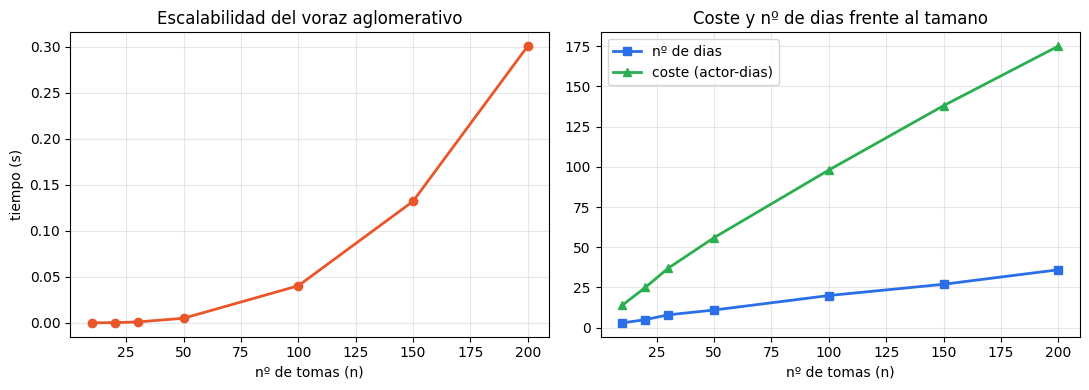

In [10]:
# =====================================================================
#  Ilustracion: escalabilidad (tiempo) y calidad (coste / nº de dias)
# =====================================================================
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(tamanos, tiempos, "o-", color="#E8562A", linewidth=2)
ax[0].set_xlabel("nº de tomas (n)"); ax[0].set_ylabel("tiempo (s)")
ax[0].set_title("Escalabilidad del voraz aglomerativo")
ax[0].grid(True, alpha=0.3)

ax[1].plot(tamanos, dias_h,   "s-", color="#2A6FE8", linewidth=2, label="nº de dias")
ax[1].plot(tamanos, costes_h, "^-", color="#2AAE4F", linewidth=2, label="coste (actor-dias)")
ax[1].set_xlabel("nº de tomas (n)")
ax[1].set_title("Coste y nº de dias frente al tamano")
ax[1].legend(); ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("escalabilidad.png", dpi=110, bbox_inches="tight")
plt.show()


## 8. Referencias

- Brassard, G. y Bratley, P. (1997). *Fundamentos de Algoritmia*. Prentice Hall.
- Duarte, A. (2008). *Metaheurísticas*. Madrid: Dykinson.
- Cormen, T. H., Leiserson, C. E., Rivest, R. L. y Stein, C. (2009). *Introduction to Algorithms* (3ª ed.). MIT Press. (Algoritmos voraces y búsqueda local.)
- Material de la asignatura **03MIAR – Algoritmos de Optimización** (VIU): enunciado del Trabajo Práctico y VC4 *(Problemas del Trabajo Práctico)*.
- Documentación de **Python 3**: operaciones a nivel de bit, `itertools`, `functools` y `random` — https://docs.python.org/3/
- **OEIS A000110** (números de Bell), usada para verificar el conteo del espacio de soluciones.


## 9. Líneas de avance y variaciones del problema

**Mejores algoritmos / metaheurísticas.** El voraz + búsqueda local encuentra buenos óptimos locales; para acercarse más al óptimo global cabría aplicar **recocido simulado (SA)**, **algoritmos genéticos (AG)** —codificando la asignación toma-día como cromosoma— o **colonias de hormigas (ACO)**. El problema también admite una **formulación exacta como Programación Lineal Entera** (modelo de *set partitioning*, con variables binarias día–toma y actor–día), resoluble con solvers (CBC, Gurobi) para obtener el óptimo garantizado en instancias medianas.

**Escalado del tamaño.** Para $n$ muy grande, el cuello de botella del voraz $O(n^3)$ se puede reducir manteniendo los pares candidatos en un **montículo (priority queue)** y actualizando sólo los afectados por cada fusión, o agrupando previamente por similitud (*clustering*) para no comparar todos los pares.

**Variaciones del problema:**

- **Coste por actor distinto** (tarifas diferentes): basta ponderar el `popcount` por un vector de tarifas.
- **Disponibilidad de actores** (un actor no puede ciertos días) o **incompatibilidades** entre tomas: se añaden como restricciones duras en la asignación.
- **Capacidad variable** por día (no siempre 6) o un **límite de días** disponibles.
- **Precedencias** entre tomas (una debe grabarse antes que otra), que convertirían el problema en uno de *scheduling* con restricciones de orden.

Todas estas extensiones encajan de forma natural en el modelo (partición de tomas + coste sobre uniones de actores), lo que confirma que la **estructura de datos elegida es robusta** frente a cambios del enunciado.
